# ▶ MAIN — Run the Whole Project

## Quantum Circuit-Based Adaptation for Credit Risk Analysis
### Variational Quantum Modeling for Portfolio Credit Risk — Team 16, Quantum Computing & Algorithms (23AID302)

**Base paper:** H. G. Ahmad et al., *"Quantum Circuit-Based Adaptation for Credit Risk Analysis,"* IEEE Trans. Quantum Eng., vol. 7, 3103316, 2026. [DOI: 10.1109/TQE.2026.3691176](https://doi.org/10.1109/TQE.2026.3691176)

---

This single notebook runs **all nine stages** of the pipeline in order — each stage notebook is executed top to bottom and saved with its fresh outputs — and then shows the headline results. Every number below is produced live by the run.

![Architecture](images/architecture_flowchart.png)

| Stage | Notebook | Architecture box |
|---|---|---|
| 0 | `00_overview.ipynb` | problem, gaps, algorithms, novelty |
| 1 | `01_classical_gci_model.ipynb` | 1. Classical GCI model (Vasicek baseline) |
| 2 | `02_quantum_encoding.ipynb` | 2. Quantum encoding $\mathrm{PD}(z)\approx\sin^2(\alpha z+\beta)$ |
| 3 | `03_circuit_design.ipynb` | 3. Circuit design (z-register + asset qubit) |
| 4 | `04_classical_training.ipynb` | 4. Classical training (parameter-shift + Adam) |
| 5 | `05_transpilation.ipynb` | 5. Transpilation (SABRE) |
| 6 | `06_hardware_retuning.ipynb` | 6A baseline grid sweep / **6B automated calibration** |
| 7 | `07_run_on_backend.ipynb` | 7. Execution on the noise-emulated backend (+ REM, ZNE) |
| 8 | `08_classical_postprocessing.ipynb` | 8. Classical post-processing (loss PDF → CDF) |
| 9 | `09_var_fidelity_check.ipynb` | 9. VaR & fidelity check → ACCEPT / RE-CALIBRATE |

## 1. Run the pipeline

`RUN_FROM = 0` runs everything (≈ 4–6 minutes on a laptop). To re-run only the later stages after stages 1–5 have been run once, set `RUN_FROM = 6`.

In [1]:
RUN_FROM = 0     # first stage to run (0..9)
RUN_TO = 9       # last stage to run

import os, sys
sys.path.insert(0, os.path.abspath("."))
from run_pipeline import run_all
run_all(start=RUN_FROM, end=RUN_TO, mode="notebooks")

 Quantum Circuit-Based Adaptation for Credit Risk Analysis -- full pipeline
 mode = notebooks, stages 0..9

>>> Stage 0: Overview


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


    executed 00_overview.ipynb (outputs saved in the notebook)
    done in 2.2 s

>>> Stage 1: Classical GCI model


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


    executed 01_classical_gci_model.ipynb (outputs saved in the notebook)
    done in 2.8 s

>>> Stage 2: Quantum encoding


...

    executed 07_run_on_backend.ipynb (outputs saved in the notebook)
    done in 15.9 s

>>> Stage 8: Classical post-processing


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


    executed 08_classical_postprocessing.ipynb (outputs saved in the notebook)
    done in 4.9 s

>>> Stage 9: VaR & fidelity check


[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


    executed 09_var_fidelity_check.ipynb (outputs saved in the notebook)
    done in 11.0 s

 Pipeline finished in 91.2 s
 Final report: /home/claude/work/results/FINAL_REPORT.md


## 2. Headline results

In [2]:
import json
import numpy as np
from src import config as C

s6 = json.load(open("results/stage06_retuning.json"))
s9 = json.load(open("results/stage09_final_report.json"))

print("STAGE 6 -- calibration of the full GCI circuit on the noisy device")
print(f"{'register':>8} | {'method':30s} | {'circuit runs':>12} | {'Hellinger fidelity':>18}")
for n in C.REGISTER_SIZES:
    g = s6[f"{n}_qubit"]["gci"]
    print(f"{n:>7}q | {'uncalibrated (Stage 4 angles)':30s} | {0:>12} | {g['uncalibrated']['fidelity']:18.4f}")
    for k, lab in [("grid_6A", "6A grid sweep (base paper)"), ("auto_6B", "6B automated (this project)")]:
        m = g["methods"][k]
        print(f"{n:>7}q | {lab:30s} | {m['n_evals']:>12} | {m['fidelity']:18.4f}")

print("\nSTAGES 7-9 -- execution, risk numbers, acceptance")
for n in C.REGISTER_SIZES:
    r = s9[f"{n}_qubit"]
    t = r["fidelity_table"]
    print(f"\n{n}-qubit register (classical VaR95 = ${r['classical_var95']:.0f})")
    for k in ["noisy_uncalibrated", "6A_grid_REM", "6B_auto_REM", "6B_auto_REM_ZNE"]:
        print(f"   {k:20s} F_H = {t[k]['F_vs_ideal_mean']:.4f} +/- {t[k]['F_vs_ideal_std']:.4f}   "
              f"P(L<=0) = {t[k]['p_loss_le_0']:.4f}   E[L] = ${t[k]['expected_loss']:.1f}   VaR95 = ${t[k]['VaR95']:.0f}")
    print(f"   deployed pipeline (6B + readout mitigation): {r['decision']}")
    seq = " -> ".join(f"{x['fidelity']:.3f} {x['decision']}" for x in r["loop_day2_drift_event"]["rounds"])
    print(f"   drift event: {seq}")

STAGE 6 -- calibration of the full GCI circuit on the noisy device
register | method                         | circuit runs | Hellinger fidelity
      2q | uncalibrated (Stage 4 angles)  |            0 |             0.9225
      2q | 6A grid sweep (base paper)     |          347 |             0.9389
      2q | 6B automated (this project)    |          204 |             0.9818
      3q | uncalibrated (Stage 4 angles)  |            0 |             0.9099
      3q | 6A grid sweep (base paper)     |          477 |             0.9570
      3q | 6B automated (this project)    |          204 |             0.9943

STAGES 7-9 -- execution, risk numbers, acceptance

2-qubit register (classical VaR95 = $1000)
   noisy_uncalibrated   F_H = 0.8794 +/- 0.0026   P(L<=0) = 0.8259   E[L] = $174.1   VaR95 = $1000
   6A_grid_REM          F_H = 0.9391 +/- 0.0022   P(L<=0) = 0.7553   E[L] = $244.7   VaR95 = $1000
   6B_auto_REM          F_H = 0.9819 +/- 0.0016   P(L<=0) = 0.7271   E[L] = $272.9   VaR95 = $

**Stage 6 — calibration cost vs quality (6A grid sweep vs 6B automated)**

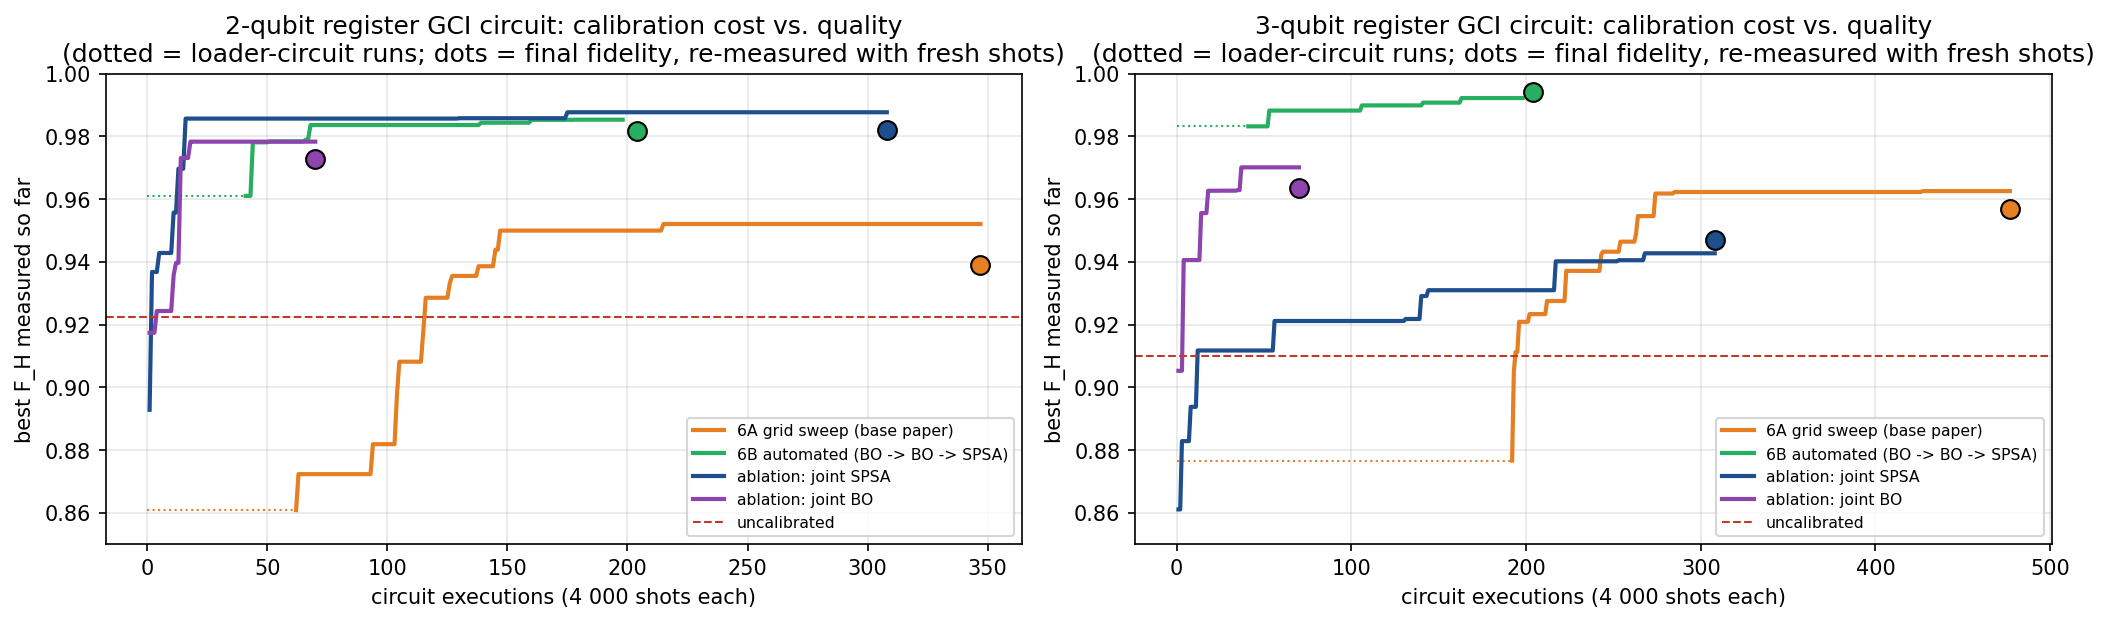

**Stage 7 — what each correction contributes**

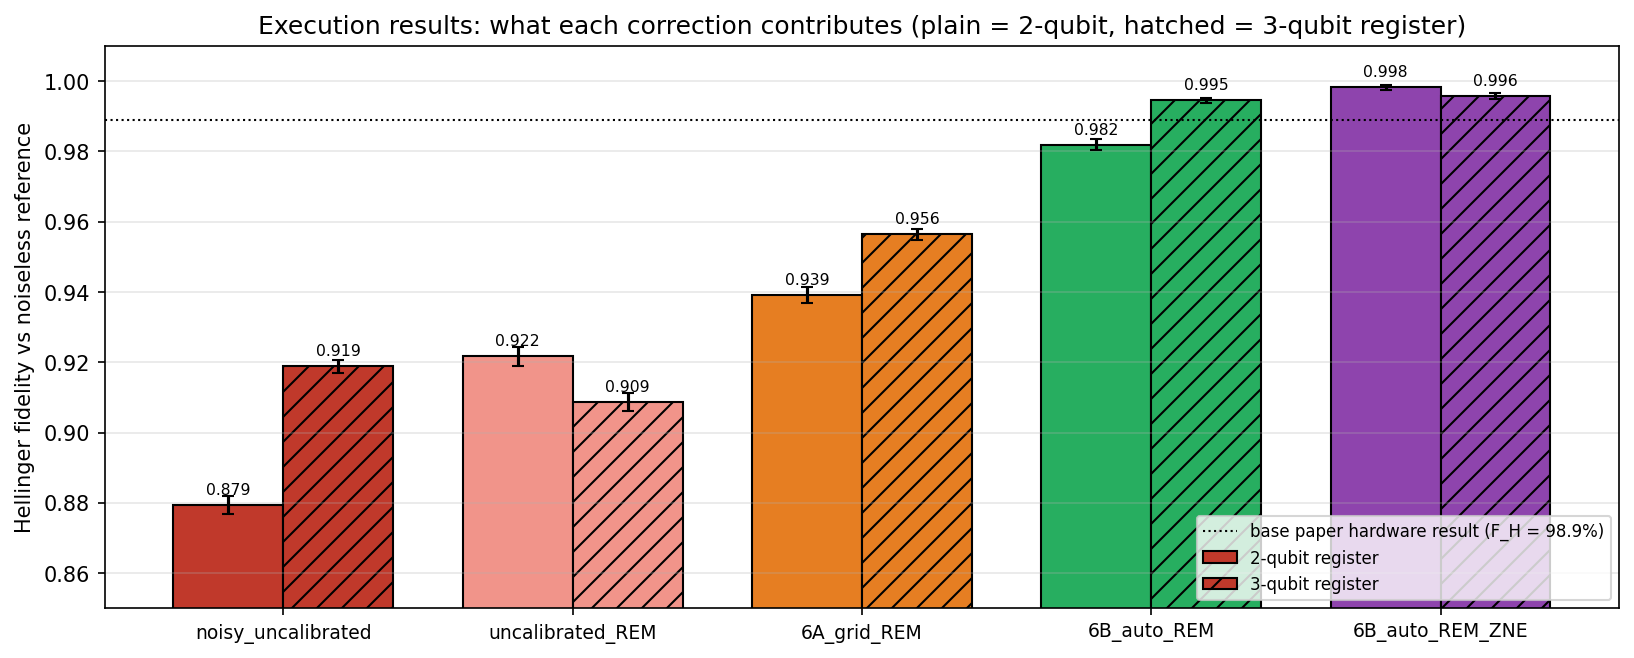

**Stage 8 — loss CDF (the paper's Fig. 10)**

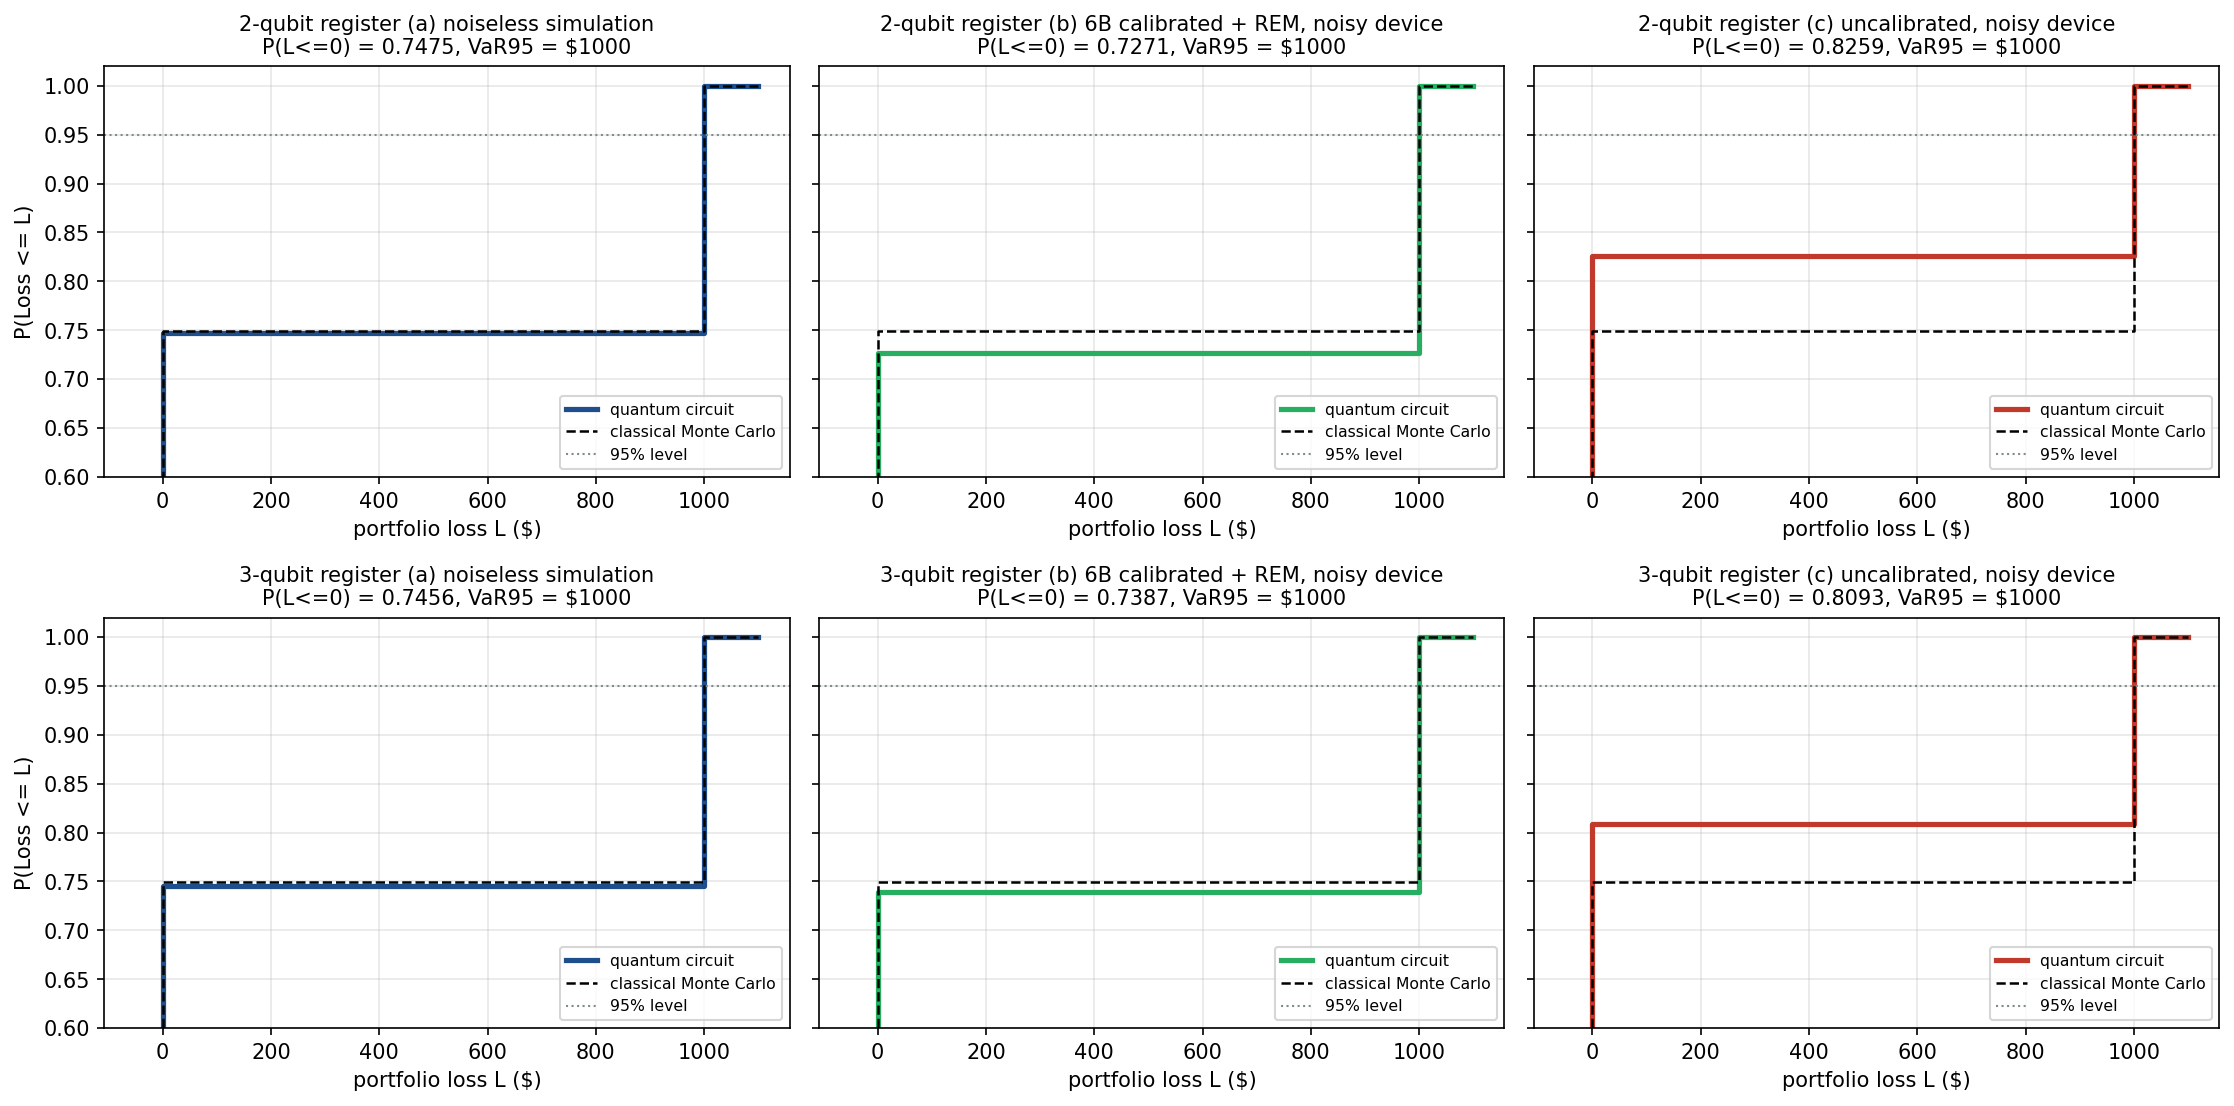

**Stage 9 — ACCEPT / RE-CALIBRATE loop after a drift event**

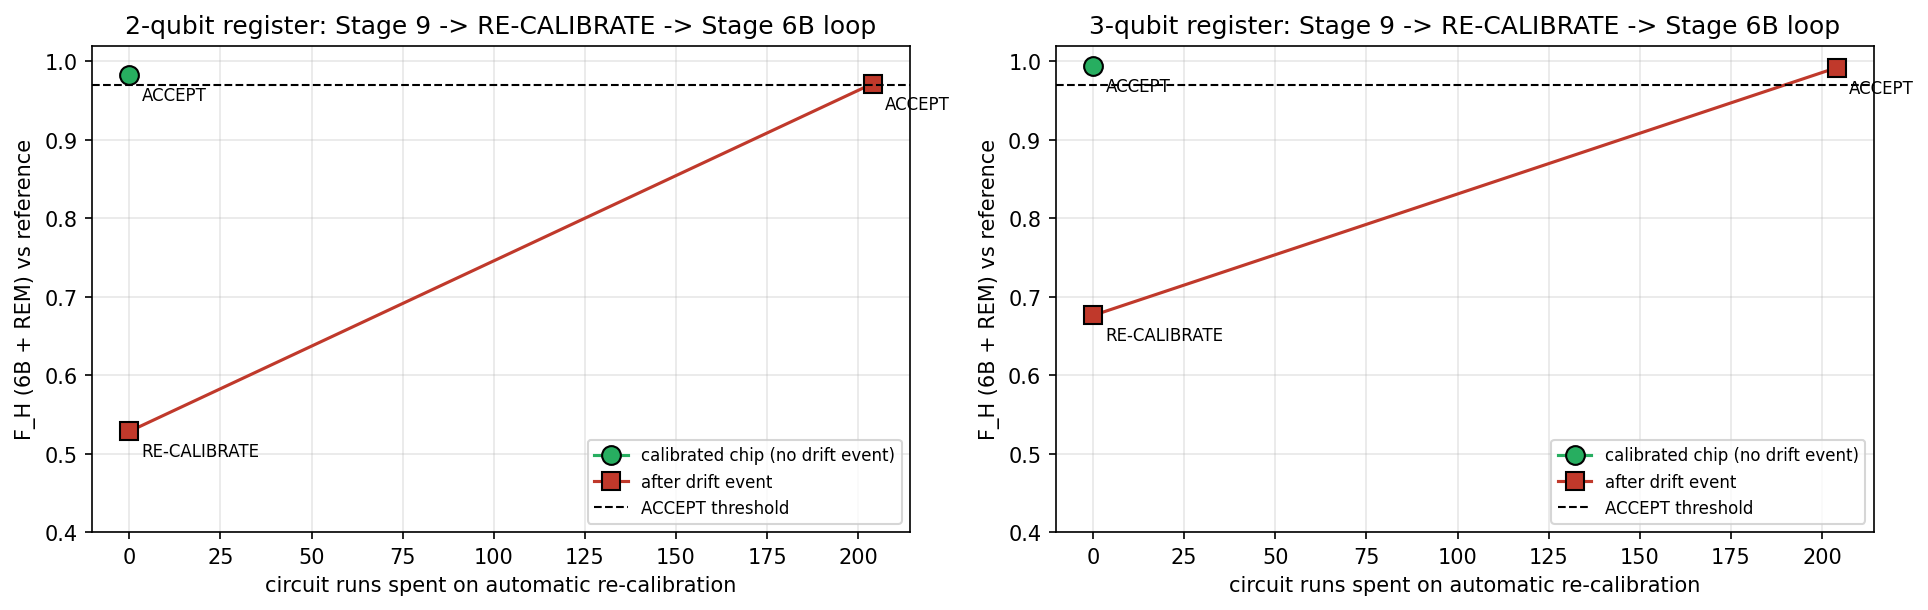

In [3]:
from IPython.display import Image, display, Markdown
for f, cap in [("stage06_convergence_gci.png", "Stage 6 — calibration cost vs quality (6A grid sweep vs 6B automated)"),
               ("stage07_fidelity_by_variant.png", "Stage 7 — what each correction contributes"),
               ("stage08_loss_cdf.png", "Stage 8 — loss CDF (the paper's Fig. 10)"),
               ("stage09_recalibration_loop.png", "Stage 9 — ACCEPT / RE-CALIBRATE loop after a drift event")]:
    display(Markdown(f"**{cap}**"))
    display(Image(filename=os.path.join("results", "figures", f), width=1000))

In [4]:
display(Markdown(open("results/FINAL_REPORT.md").read()))

# Final Report — Quantum Circuit-Based Adaptation for Credit Risk Analysis

Replication (on a noise-emulated Qiskit simulator) of Ahmad et al., *IEEE Trans. Quantum Eng.* 7, 3103316 (2026), with an automated calibration loop replacing the paper's manual grid sweep.

Model: one asset, one latent factor, p0 = 0.25, rho = 0.027, LGD = $1000. Registers studied: 2-qubit, 3-qubit latent-factor register (+1 asset qubit).

## Stage 6 — calibration cost vs. quality (full GCI circuit)

| register | method | circuit runs | F_H vs noiseless reference |
|---|---|---|---|
| 2q | uncalibrated (Stage 4 angles) | 0 | 0.9225 |
| 2q | 6A grid sweep (base paper) | 347 | 0.9389 |
| 2q | **6B automated (this project)** | 204 | 0.9818 |
| 2q | ablation: joint SPSA | 308 | 0.9820 |
| 2q | ablation: joint BO | 70 | 0.9727 |
| 3q | uncalibrated (Stage 4 angles) | 0 | 0.9099 |
| 3q | 6A grid sweep (base paper) | 477 | 0.9570 |
| 3q | **6B automated (this project)** | 204 | 0.9943 |
| 3q | ablation: joint SPSA | 308 | 0.9469 |
| 3q | ablation: joint BO | 70 | 0.9637 |

## Stage 7/8/9 — execution (20 x 20,000 shots) and risk numbers

| register | variant | F_H vs ideal | F_H vs classical GCI | P(L<=0) | E[L] ($) | VaR95 ($) |
|---|---|---|---|---|---|---|
| 2q | ideal_noiseless | 1.0000 ± 0.0000 | 1.0000 | 0.7475 | 252.5 ± 0.0 | 1000 |
| 2q | noisy_uncalibrated | 0.8794 ± 0.0026 | 0.8802 | 0.8259 | 174.1 ± 3.1 | 1000 |
| 2q | uncalibrated_REM | 0.9218 ± 0.0027 | 0.9226 | 0.8347 | 165.3 ± 3.4 | 1000 |
| 2q | 6A_grid_REM | 0.9391 ± 0.0022 | 0.9394 | 0.7553 | 244.7 ± 2.8 | 1000 |
| 2q | 6B_auto_REM | 0.9819 ± 0.0016 | 0.9820 | 0.7271 | 272.9 ± 3.5 | 1000 |
| 2q | 6B_auto_REM_ZNE | 0.9983 ± 0.0007 | 0.9983 | 0.7419 | 258.1 ± 4.6 | 1000 |
| 2q | classical discrete-grid GCI | — | 1 | 0.7496 | 250.4 | 1000 |
| 3q | ideal_noiseless | 1.0000 ± 0.0000 | 0.7829 | 0.7456 | 254.4 ± 0.0 | 1000 |
| 3q | noisy_uncalibrated | 0.9189 ± 0.0018 | 0.7752 | 0.8093 | 190.7 ± 2.7 | 1000 |
| 3q | uncalibrated_REM | 0.9087 ± 0.0025 | 0.7473 | 0.8160 | 184.0 ± 2.9 | 1000 |
| 3q | 6A_grid_REM | 0.9564 ± 0.0015 | 0.7802 | 0.7375 | 262.5 ± 2.1 | 1000 |
| 3q | 6B_auto_REM | 0.9946 ± 0.0007 | 0.8149 | 0.7387 | 261.3 ± 3.6 | 1000 |
| 3q | 6B_auto_REM_ZNE | 0.9958 ± 0.0008 | 0.8000 | 0.7701 | 229.9 ± 4.2 | 1000 |
| 3q | classical discrete-grid GCI | — | 1 | 0.7500 | 250.0 | 1000 |

## Stage 9 — acceptance test (threshold F_H >= 0.97)

- **2-qubit register:** deployed pipeline (6B + readout mitigation) F_H = 0.9819 → **ACCEPT**.
  - drift event (new miscalibration): 0.528 (RE-CALIBRATE) → 0.972 (ACCEPT); 204 circuit runs of automatic re-calibration.
- **3-qubit register:** deployed pipeline (6B + readout mitigation) F_H = 0.9946 → **ACCEPT**.
  - drift event (new miscalibration): 0.676 (RE-CALIBRATE) → 0.992 (ACCEPT); 204 circuit runs of automatic re-calibration.

## Comparison with the base paper

- Paper (real Contralto-D chip, no mitigation): F_H = 98.9 ± 0.3 %, P(L<=0) ≈ 0.75, P(L<=1000) = 1, VaR95 = $1000.
- This project (noise-emulated simulator, 6B + readout mitigation): 2q F_H = 98.2 %, 3q F_H = 99.5 %; P(L<=0) = 0.727 (2q), 0.739 (3q); VaR95 = $1000 in every repetition.
- 2-qubit loader: the paper-style 6A sweep moves theta_1 from the trained 195° to 234°; the paper's hardware sweeps found 237° (D3–C4) and 224° (D3–A6).

*All numbers come from a simulator with an emulated noise model — no claim of physical QPU execution.*
